In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [225]:
df = pd.read_csv("/Users/arpananand/Downloads/Projects/Loan Projects/CEP_2_Datasets/loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [227]:
df.select_dtypes(include=[np.number]).describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [228]:
df['not.fully.paid'].value_counts()

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

### Analysis 
Data is imbalanced so we need to use techniques to handle imbalanced data like SMOTE.

In [229]:
df.purpose.value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

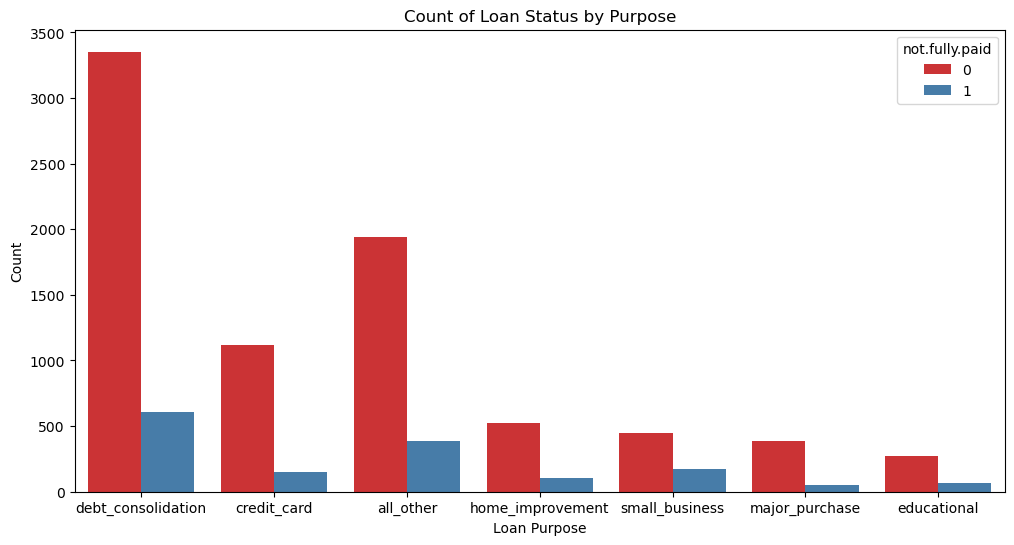

In [230]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='purpose', hue='not.fully.paid', palette='Set1')

plt.title('Count of Loan Status by Purpose')
plt.ylabel('Count')
plt.xlabel('Loan Purpose')

plt.show()


In [231]:
df = pd.get_dummies(df, columns=['purpose'], drop_first=True, dtype=int)
df.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1,0,0,0,0,0


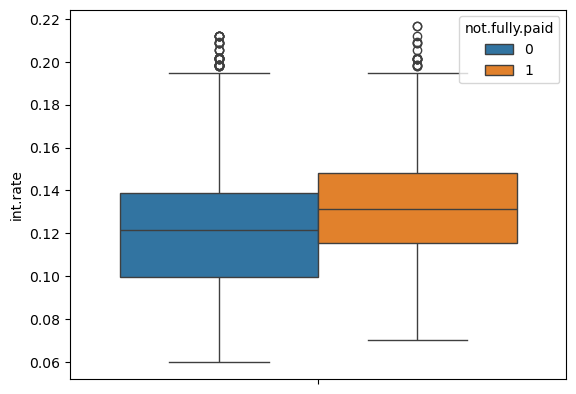

In [232]:
sns.boxplot(data=df, y='int.rate', hue='not.fully.paid')
plt.show()

### Analysis
We can see that the mean of the interest rate for people who didn't pay the loan is higher than people who did pay

/var/folders/kv/329nwfzj7vb086btrz5x67l00000gn/T/ipykernel_20874/20078723.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/kv/329nwfzj7vb086btrz5x67l00000gn/T/ipykernel_20874/20078723.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/kv/329nwfzj7vb086btrz5x67l00000gn/T/ipykernel_20874/20078723.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/kv/329nwfzj7vb086btrz5x67l00000gn/T/ipykernel_20874/20078723.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

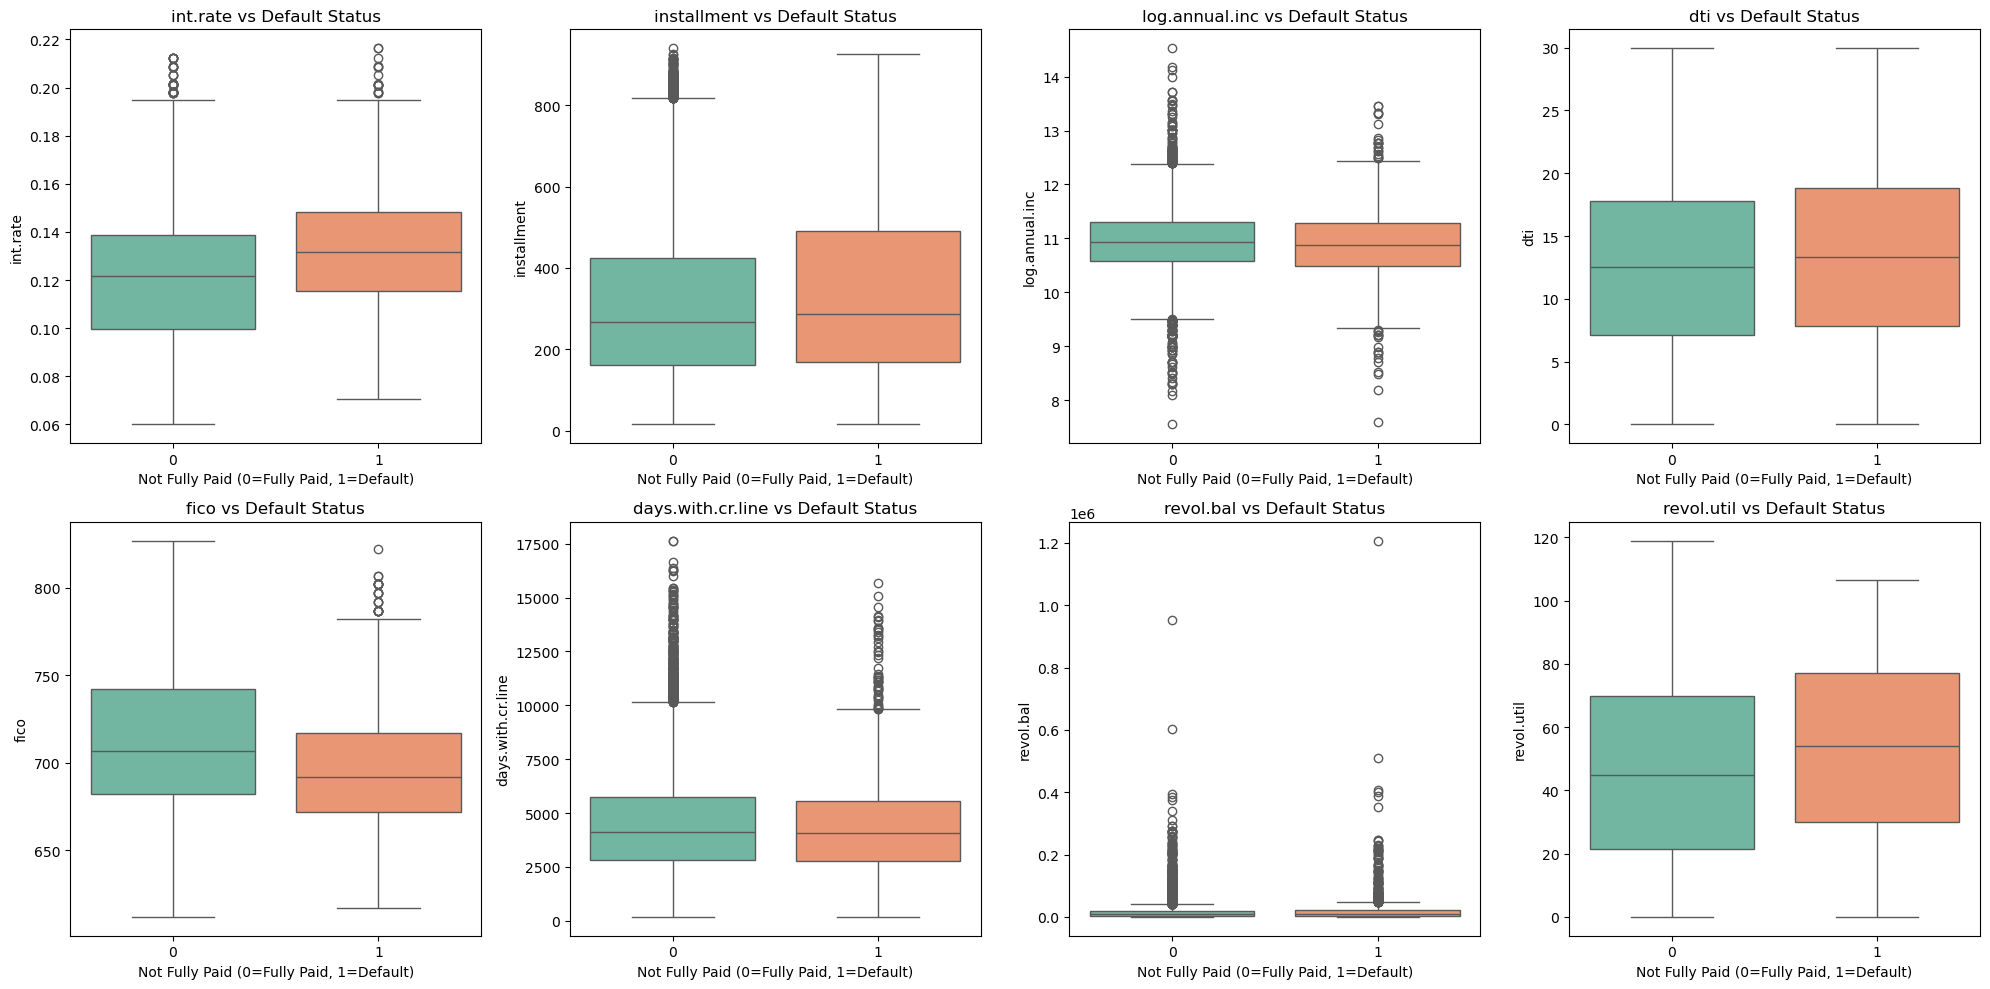

In [ ]:
columns_to_plot = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 
                   'days.with.cr.line', 'revol.bal', 'revol.util']

num_cols = 4
num_rows = (len(columns_to_plot) + num_cols - 1) // num_cols 

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.boxplot(
        data=df, 
        x='not.fully.paid', 
        y=col, 
        ax=axes[i],     
        palette='Set2'
    )
    axes[i].set_title(f'{col} vs Default Status')
    axes[i].set_xlabel('Not Fully Paid (0=Fully Paid, 1=Default)')

for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Analysis

people who dont pay the loan has lower fico.<br>
people who dont pay the loan has higher credit utization.<br>
dti don't have any partiulcar relation with defaulting.<br>
mean interest rate is slighter higher for the defaulters.<br>
A lot of defaulter have higher installment.<br>


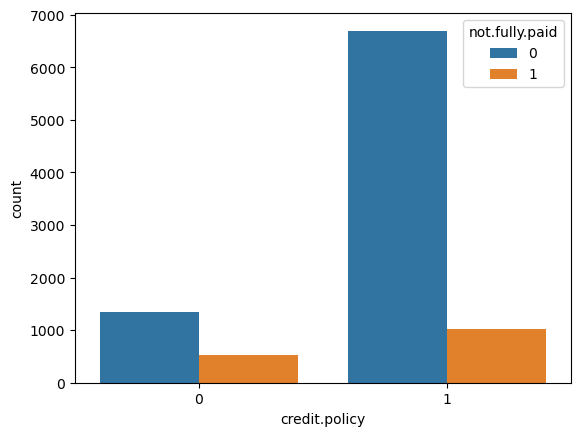

In [234]:
sns.countplot(data=df, x='credit.policy', hue='not.fully.paid')
plt.show()

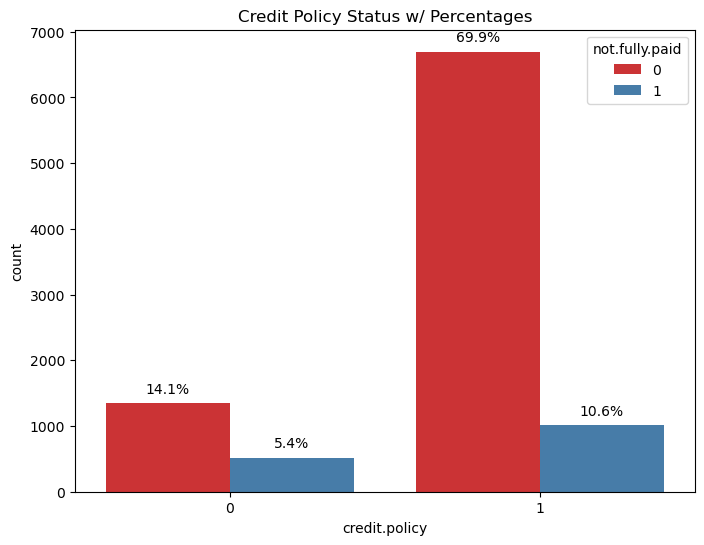

In [ ]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x='credit.policy', hue='not.fully.paid', palette='Set1')
total = len(df)
for p in ax.patches:
    height = p.get_height()
    if not str(height) == 'nan' and height > 0:
        percentage = f'{100 * height / total:.1f}%'
        ax.annotate(percentage, 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', # Align the text centrally and above the bar 
                    fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.title('Credit Policy Status w/ Percentages')
plt.show()


In [236]:
df['extreme_risk'] = df['revol.util'] * df['dti']
df['fico'] = pd.cut(df['fico'], bins=[0, 649, 699, 749, 900], labels=[0, 1, 2, 3])
df = pd.get_dummies(df, columns=['fico'], drop_first=True, dtype=int)

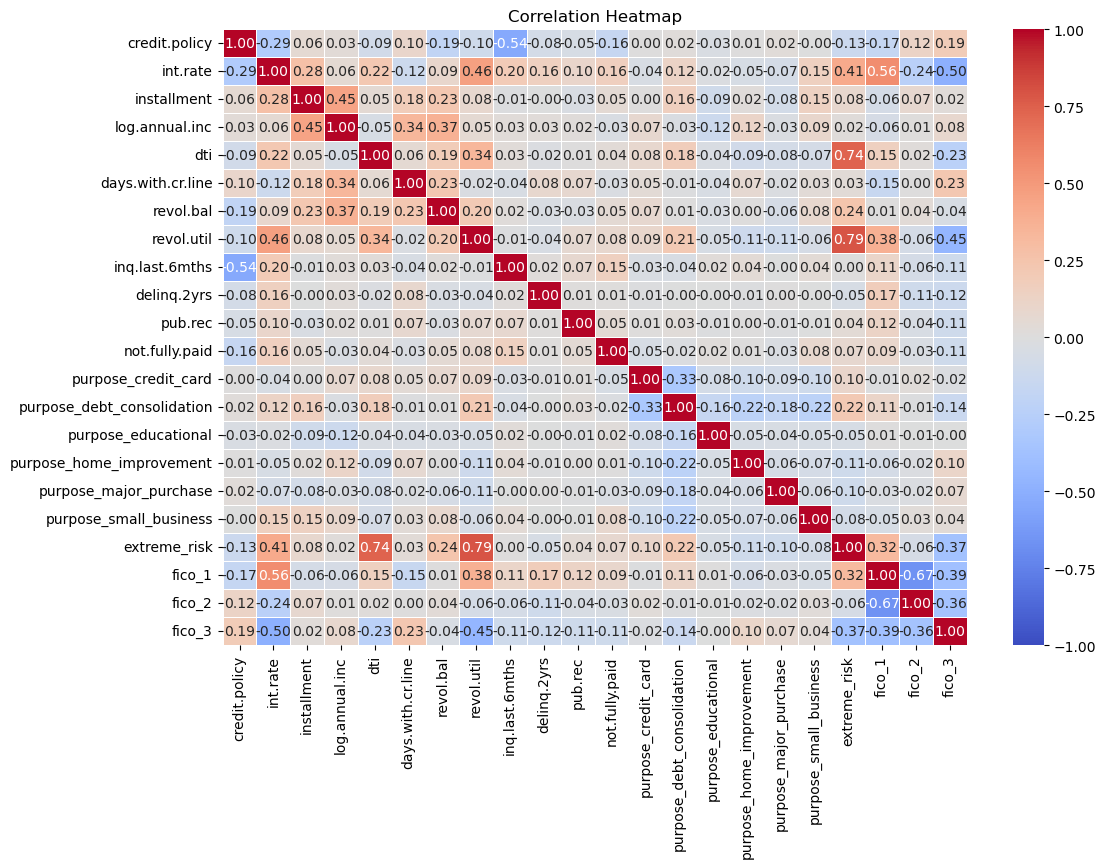

In [237]:

# 1. Calculate the correlation matrix
corr = df.corr()

# 2. Set up the matplotlib figure size (make it large enough to read easily)
plt.figure(figsize=(12, 8))

# 3. Create the heatmap
sns.heatmap(
    corr, 
    annot=True,       # Shows the actual correlation numbers inside the boxes
    cmap='coolwarm',  # A good color scheme (red for positive corr, blue for negative)
    fmt=".2f",        # Rounds the numbers to 2 decimal places so it's not messy
    linewidths=0.5,   # Adds thin white lines between the boxes for clarity
    vmin=-1, vmax=1   # Locks the color scale from -1 (perfect negative) to 1 (perfect positive)
)

plt.title('Correlation Heatmap')
plt.show()


In [238]:
strong_corr = corr[((corr > 0.4) | (corr < -0.4)) & (corr != 1.0)]
strong_corr = strong_corr.dropna(how='all', axis=0).dropna(how='all', axis=1)
strong_corr

,credit.policy,int.rate,installment,log.annual.inc,dti,revol.util,inq.last.6mths,extreme_risk,fico_1,fico_2,fico_3
credit.policy,NaN,NaN,NaN,NaN,NaN,NaN,-0.535511,NaN,NaN,NaN,NaN
int.rate,NaN,NaN,NaN,NaN,NaN,0.464837,NaN,0.412888,0.559368,NaN,-0.495157
installment,NaN,NaN,NaN,0.448102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
log.annual.inc,NaN,NaN,0.448102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.740157,NaN,NaN,NaN
revol.util,NaN,0.464837,NaN,NaN,NaN,NaN,NaN,0.793004,NaN,NaN,-0.454592
inq.last.6mths,-0.535511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
extreme_risk,NaN,0.412888,NaN,NaN,0.740157,0.793004,NaN,NaN,NaN,NaN,NaN
fico_1,NaN,0.559368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.668498,NaN
fico_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.668498,NaN,NaN


### Analysis

we can see that as fico goes lower interst rates go up.<br>
As inquiry in last 6 months increases the chances of getting credit policy = 1 reduces.<br>
As credit utilization increases so does interest rate.<br>
As credit utilization increases it reduces fico.<br>
As annual income increases installment amount increases.<br>
as fico decreases the credit utilization increases as having maxed out credit utilization will impact fico.

In [239]:
df = df.drop('int.rate', axis=1)
df.head()

,credit.policy,installment,log.annual.inc,dti,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,...,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,extreme_risk,fico_1,fico_2,fico_3
0,1,829.10,11.350407,19.48,5639.958333,28854,52.1,0,0,0,...,0,1,0,0,0,0,1014.908,0,1,0
1,1,228.22,11.082143,14.29,2760.000000,33623,76.7,0,0,0,...,1,0,0,0,0,0,1096.043,0,1,0
2,1,366.86,10.373491,11.63,4710.000000,3511,25.6,1,0,0,...,0,1,0,0,0,0,297.728,1,0,0
3,1,162.34,11.350407,8.10,2699.958333,33667,73.2,1,0,0,...,0,1,0,0,0,0,592.920,0,1,0
4,1,102.92,11.299732,14.97,4066.000000,4740,39.5,0,1,0,...,1,0,0,0,0,0,591.315,1,0,0


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test) # Transform the test set using the same rules
print("Before SMOTE, Default cases in train:", sum(y_train == 1))
print("After SMOTE, Default cases in train:", sum(y_train_smote == 1))
print(f"X_train_scaled shape: {X_train_scaled.shape}")


Before SMOTE, Default cases in train: 1228
After SMOTE, Default cases in train: 6434
X_train_scaled shape: (12868, 20)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(Dense(78, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))

model.add(Dense(39, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(19, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

print("Starting to train the deep learning model...")
model.fit(
    x=X_train_scaled, 
    y=y_train_smote, 
    epochs=50, 
    batch_size=256,
    validation_data=(X_test_scaled, y_test), 
    callbacks=[early_stop]
)


Starting to train the deep learning model...
Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6902 - loss: 0.6191 - val_accuracy: 0.7740 - val_loss: 0.5019
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7781 - loss: 0.4949 - val_accuracy: 0.7829 - val_loss: 0.4944
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7921 - loss: 0.4582 - val_accuracy: 0.8006 - val_loss: 0.4887
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7983 - loss: 0.4435 - val_accuracy: 0.8079 - val_loss: 0.4821
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7976 - loss: 0.4365 - val_accuracy: 0.8132 - val_loss: 0.4730
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7983 - loss: 0.4345 - val_accuracy: 0.8132 - val_loss: 0.4802
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8037 - loss: 0.4257 - val_accuracy: 0.8069 - val_loss: 0.4871
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8056 - loss: 0.4269 - val_accuracy: 0.7933 - val_loss: 0.5088
Epo

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(X_test_scaled)
predictions = (predictions > 0.5).astype(int)

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, predictions))

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step

--- Confusion Matrix ---
[[1471  140]
 [ 247   58]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1611
           1       0.29      0.19      0.23       305

    accuracy                           0.80      1916
   macro avg       0.57      0.55      0.56      1916
weighted avg       0.77      0.80      0.78      1916

